In [ ]:
import torch
from torch import nn

import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor

import matplotlib.pyplot as plt

torch.__version__

'2.10.0'

In [2]:
# Setup training data
train_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
    target_transform=None
)

# Setup testing data
test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
    target_transform=None
)

# Parameter definitions can be gotten from https://docs.pytorch.org/vision/stable/generated/torchvision.datasets.FashionMNIST.html#torchvision.datasets.FashionMNIST

In [3]:
# We unpack the tuple to inspect the data
# The pixels stand for the numeric (tensor) representation of the clothing item
pixels, category = train_data[0]
pixels

tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
          0.2863, 0.0000, 0.0000, 0.0039, 0.0157, 0.0000,

In [4]:
# 9 is the category of above image, could be a shoe, who knows
category

9

In [5]:
pixels.shape

torch.Size([1, 28, 28])

The shape suggests that the height of the image is 28 pixels, the width is also 28 pixels, and the color channels 1.
[color_channels = 1, height = 28, width = 28]
Color channels is kind of like the color that the image has, be it a greyscale image, or colored image with 3 as it's color scale representing RGB

In [6]:
# Now we check how many samples exist
len(train_data.data), len(train_data.targets), len(test_data.data), len(test_data.targets)

(60000, 60000, 10000, 10000)

We have 60,000 training samples and 10,000 testing samples

In [7]:
# Now we check the names of the targets using .classes
class_names = train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

Since train_data.classes is a list, we can see what clothing types are in the first 10 images.
Just for fun

In [8]:
for i in range(10):
    pixels, category = train_data[i]
    print(train_data.classes[category])

Ankle boot
T-shirt/top
T-shirt/top
Dress
T-shirt/top
Pullover
Sneaker
Pullover
Sandal
Sandal


Clothing Shape {torch.Size([1, 28, 28])}


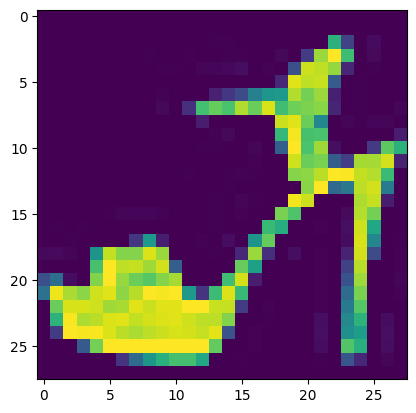

In [9]:
# Visualize
print(f"Clothing Shape",{pixels.shape})
plt.imshow(pixels.squeeze())

Looks like the first item is actually a type of shoe.
matplotlib will take in a 2d shape to make a plot, but as our tensor is 3d([1, 28, 28]), we use .squeeze
This basically removes an dimension that has a size of exactly 1, and that would remove our greyscale color, thus why we're having this neon one.

Clothing Shape {torch.Size([1, 28, 28])}


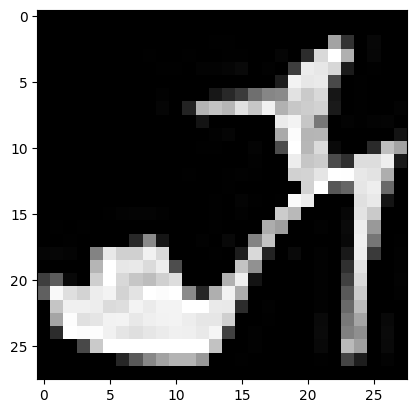

In [10]:
# Visualize again
print(f"Clothing Shape",{pixels.shape})
plt.imshow(pixels.squeeze(), cmap='grey')

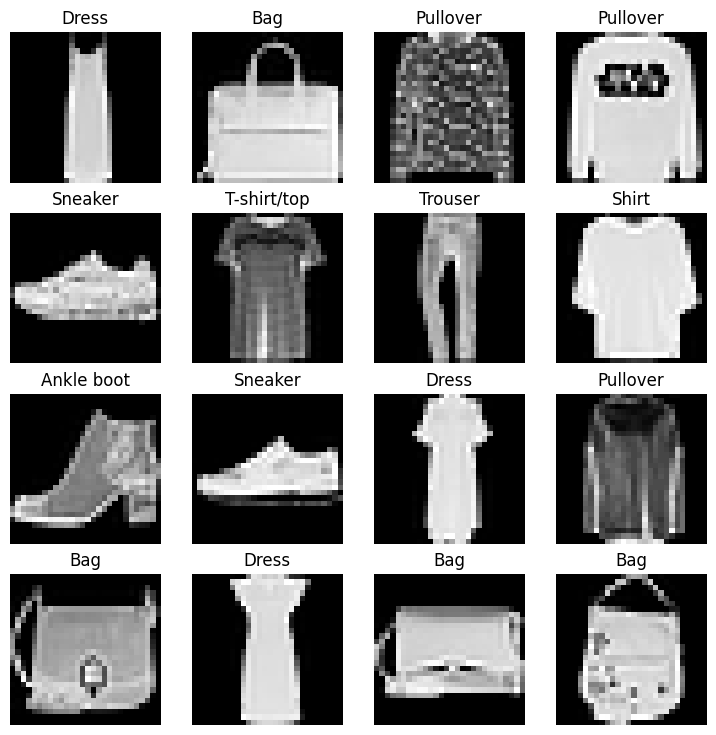

In [11]:
# Plot more images
# torch.manual_seed(42)
fig = plt.figure(figsize=(9,9))
rows, cols = 4,4
for i in range(1, rows * cols + 1):
    random_idx = torch.randint(0, len(train_data), size=[1]).item()
    img, label = train_data[random_idx]
    fig.add_subplot(rows, cols, i)
    plt.imshow(img.squeeze(), cmap="gray")
    plt.title(class_names[label])
    plt.axis(False)

In [12]:
train_data[4]

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.1020, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.7412, 0.8078, 0.7333, 0.1255, 0.0000, 0.0000, 0.0000, 0.1020,
           0.8510, 0.8863, 0.7686, 0.0431, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.7529, 0.8902, 0.9176, 0.9529, 0.9020, 0.5765, 0.9373, 0.9490,
           0.9176, 0.8549, 0.8196, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.6784, 0.8824, 0.8431, 0.9137, 0.9961, 0.0000, 0.7608, 0.9412,
           0.8510, 0.8667, 0.7451, 0.0000, 

In [13]:
# Setting up a dataloader to pass the data into the model
from torch.utils.data import DataLoader


# Setup the batch size hyperparameter
BATCH_SIZE = 32

# Transform the dataset into batches
train_dataloader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)

In [14]:
print(f"DataLoaders: {train_dataloader, test_dataloader}")
print(f"Length of train dataloader {len(train_dataloader)} batches of {BATCH_SIZE}")
print(f"Length of test dataloader {len(test_dataloader)} batches of {BATCH_SIZE}")

DataLoaders: (<torch.utils.data.dataloader.DataLoader object at 0x116aa4ec0>, <torch.utils.data.dataloader.DataLoader object at 0x1170b7250>)
Length of train dataloader 1875 batches of 32
Length of test dataloader 313 batches of 32


In [15]:
print(train_dataloader)

In [16]:
# Check out what's inside the training dataloader
# Using the next() and iter() to extract the data into new variables
train_features_batch, train_labels_batch = next(iter(train_dataloader))
train_features_batch.shape, train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

Image size: torch.Size([1, 28, 28])
Label: 9, label size: torch.Size([])


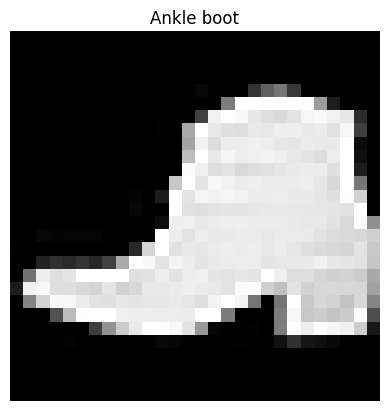

In [17]:
# Show a sample
torch.manual_seed(42)
random_idx = torch.randint(0, len(train_features_batch), size=[1]).item()
img, label = train_features_batch[random_idx], train_labels_batch[random_idx]
plt.imshow(img.squeeze(), cmap="gray")
plt.title(class_names[label])
plt.axis("Off");
print(f"Image size: {img.shape}")
print(f"Label: {label}, label size: {label.shape}")

Now we create the first model

In [18]:
from torch import nn
class FashionMNISTModelV0(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=input_shape, out_features=hidden_units),
            nn.Linear(in_features=hidden_units, out_features=output_shape)
        )

    def forward(self, x):
        return self.layer_stack(x)

In [19]:
torch.manual_seed(42)

model_0 = FashionMNISTModelV0(input_shape=784, hidden_units=10, output_shape=len(class_names))
model_0.to('cpu')

FashionMNISTModelV0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

We've set the optimizer and loss functions, and we can begin training our model, but how about an experiment first.
Our model will be trained on our CPU, but we can also train it our GPU, and observe the time it takes for both devices to run the training.

In [33]:
import requests
from pathlib import Path 

# Download helper functions from Learn PyTorch repo (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  # Note: you need the "raw" GitHub URL for this to work
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

In [ ]:
from helper_functions import accuracy_fn

# Setup loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.1)

In [23]:
# To do this we import timeit.default_timer
from timeit import default_timer as timer

def print_train_time(start: float, end: float, device: torch.device = None):
    """Prints difference between start and end time.

    Args:
        start (float): Start time of computation (preferred in timeit format). 
        end (float): End time of computation.
        device ([type], optional): Device that compute is running on. Defaults to None.

    Returns:
        float: time between start and end in seconds (higher is longer).
    """
    total_time = end - start
    print(f"Train time on {device}: {total_time:.3f} seconds")
    return total_time

In [47]:
from tqdm.auto import tqdm

# Set the seed and set the timer
torch.manual_seed(42)
train_time_start_on_cpu = timer()

epochs = 3

# Create training and testing loop
for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n---------")
    ### Training
    train_loss = 0
    # Add a loop to loop through training batches
    for batch, (X, y) in enumerate(train_dataloader):
        model_0.train()

        # Forward pass
        y_pred = model_0(X)

        # Calculate loss
        loss = loss_fn(y_pred, y)
        train_loss += loss

        # Clear previous gradients so they don't accumulate
        optimizer.zero_grad()

        # Calculate loss gradients
        loss.backward()

        # Update parameters
        optimizer.step()

        if batch % 400 == 0:
            print(f"Looked at {batch * len(X)}/{len(train_dataloader)} samples")
        
    train_loss /= len(train_dataloader)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
---------
Looked at 0/1875 samples
Looked at 12800/1875 samples
Looked at 25600/1875 samples
Looked at 38400/1875 samples


 33%|███▎      | 1/3 [00:01<00:02,  1.14s/it]

Looked at 51200/1875 samples
Epoch: 1
---------
Looked at 0/1875 samples
Looked at 12800/1875 samples
Looked at 25600/1875 samples
Looked at 38400/1875 samples


 67%|██████▋   | 2/3 [00:02<00:01,  1.12s/it]

Looked at 51200/1875 samples
Epoch: 2
---------
Looked at 0/1875 samples
Looked at 12800/1875 samples
Looked at 25600/1875 samples
Looked at 38400/1875 samples


100%|██████████| 3/3 [00:03<00:00,  1.12s/it]

Looked at 51200/1875 samples


In [48]:
### Testing
test_loss, test_acc = 0.0, 0.0
model_0.eval()

with torch.inference_mode():
    for X, y in test_dataloader:

        test_pred = model_0(X)

        test_loss += loss_fn(test_pred, y)

        test_acc += accuracy_fn(y_true=y, y_pred=test_pred.argmax(dim=1))

    test_loss /= len(test_dataloader)

    test_acc /= len(test_dataloader)

print(f"\nTrain loss: {train_loss:.5f} | Test loss: {test_loss:.5f}, Test Accuracy: {test_acc:.2f}%\n")

# Calculate training time
train_time_end_on_cpu = timer()
total_train_time_model_0 = print_train_time(start=train_time_start_on_cpu, end=train_time_end_on_cpu, device=str(next(model_0.parameters()).device))


Train loss: 0.39663 | Test loss: 0.48361, Test Accuracy: 83.21%

Train time on cpu: 6.369 seconds


In [50]:
torch.manual_seed(42)
def eval_model(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               accuracy_fn):
    """Returns a dictionary containing containing the results of the model predicting on dataloader
    
    Args:
        model (torch.nn.Module): A PyTorch model capable of making predictions on data_loader.
        data_loader (torch.utils.data.Dataloader): The target dataset to predict.
        loss_fn (torch.nn.Module): The loss function of the model.
        accuracy_fn: An accuracy function to compare the model's predictions to the truth labels.
          
    Returns:
        (dict): Results of model making predictions on data_loader.
"""
    loss, acc = 0, 0
    model.eval()
    with torch.inference_mode():
        for X, y in data_loader:
            y_pred = model(X)

            loss += loss_fn(y_pred, y)
            acc += accuracy_fn(y_true=y, y_pred=y_pred.argmin(dim=1)) 

        loss /= len(data_loader)
        acc /= len(data_loader)

    return {"model_name": model.__class__.__name__,
            "model_loss": loss.item(),
            "model_acc": acc}

# Calculate model 0 results on test dataset
model_0_results = eval_model(model=model_0, 
                             data_loader=test_dataloader, 
                             loss_fn=loss_fn,
                             accuracy_fn=accuracy_fn)

model_0_results

{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.4836065173149109,
 'model_acc': 0.009984025559105431}

In [52]:
device = "mps"
device

'mps'

In [54]:
# Create a model with non-linear layers
class FashionMNISTModelV1(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=input_shape, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=output_shape),
            nn.ReLU(),      
        )
    def forward(self, x: torch.Tensor):
        return self.layer_stack(x)

In [59]:
# Instantiate model
torch.manual_seed(42)
model_1 = FashionMNISTModelV1(input_shape=786, hidden_units=10, output_shape=len(class_names)).to(device)
next(model_1.parameters()).device

device(type='mps', index=0)

In [56]:
print(next(model_1.parameters()))

Parameter containing:
tensor([[ 0.0273,  0.0296, -0.0084,  ...,  0.0135, -0.0188, -0.0354],
        [ 0.0187,  0.0085, -0.0181,  ...,  0.0017,  0.0045,  0.0133],
        [-0.0108, -0.0213,  0.0084,  ...,  0.0026,  0.0231,  0.0155],
        ...,
        [ 0.0055,  0.0044,  0.0025,  ...,  0.0163,  0.0223, -0.0069],
        [ 0.0233, -0.0007, -0.0126,  ...,  0.0082,  0.0110,  0.0066],
        [ 0.0329,  0.0033,  0.0030,  ..., -0.0120,  0.0228,  0.0321]],
       device='mps:0', requires_grad=True)


In [ ]:
# Setup loss, optimizer, and evaluation metrics
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_1.parameters(), lr=0.1)

In [66]:
def train_step(model: nn.Module,
               dataloader:torch.utils.data.DataLoader,
               optimizer: torch.optim.Optimizer,
               loss_fn: torch.nn.Module,
               accuracy_fn,
               device: torch.device = device):
    train_loss, train_acc = 0, 0
    model.to(device)
    for batch, (X,y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        y_pred = model(X)

        loss = loss_fn(y_pred, y)
        train_loss += loss
        train_acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

    # Calculate the average loss and accuracy of the batches
    train_loss /= len(dataloader)
    train_acc /= len(dataloader)
    print(f"Train loss {train_loss:.5f} | Train Accuracy {train_acc:.2f}%")


In [68]:
def test_step(model: nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              accuracy_fn,
              device: torch.device = device):
    test_loss, test_acc = 0,0
    model.to(device)
    model.eval()
    with torch.inference_mode():
        for X,y in dataloader:
            # Send data to GPU
            X,y = X.to(device), y.to(device)

            test_pred = model(X)

            loss = loss_fn(test_pred, y)
            test_loss += loss
            test_acc += accuracy_fn(y_true=y, y_pred=test_pred.argmax(dim=1))

    # Calculate average test loss and accuracy
    test_loss /= len(dataloader)
    test_acc /= len(dataloader)
    print(f"Test loss {test_loss:.5f} | Test accuracy {test_acc:.2f}%")



In [ ]:
torch.manual_seed(42)

# Measure time
from timeit import default_timer as timer
train_time_start_on_gpu = timer()

epochs = 3
for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n-----")
    train_step(model = model_1,
               dataloader=train_dataloader, 
               optimizer=optimizer,
               loss_fn=loss_fn,
               accuracy_fn=accuracy_fn)
    test_step(model=model_1,
              dataloader=test_dataloader,
              loss_fn=loss_fn,
              accuracy_fn=accuracy_fn)